In [1]:
# some useful libraries for this notebook
import requests
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import time


In [2]:
# OpenAIRE's Graph API is fully public and needs no API key.
# Note: not all entity types are on the same API version -- researchProducts uses v2, links uses v1.
BASE_V2 = "https://api.openaire.eu/graph/v2"
BASE_V1 = "https://api.openaire.eu/graph/v1"


### 1) Retrieve a single work by identifier

This code snippet demonstrates how to look up a work by its DOI using the OpenAIRE Graph API, extract key metadata fields, and print them in a readable format.

You can modify the `DOI` variable to look up a different work. The `pid` parameter accepts any persistent identifier: DOI, PMID, PMCID, arXiv ID, Handle.

API docs: https://graph.openaire.eu/docs/apis/graph-api/searching-entities/filtering-search-results


In [3]:
### Settings
# Replace with the identifier you want to look up
DOI = "10.1016/j.joi.2017.08.007"


In [4]:
### Fetch
# The `pid` parameter matches any persistent identifier, including DOIs
response = requests.get(
    f"{BASE_V2}/researchProducts",
    params={"pid": DOI, "pageSize": 1},
)
response.raise_for_status()
results = response.json().get("results") or []
work = results[0] if results else None


In [5]:
### Display key metadata
# Tip: to check available fields, you can print `work.keys()` or refer to the API documentation
if work is None:
    print("No result found for this DOI.")
else:
    print("Title      :", work.get("mainTitle"))
    print("DOI        :", DOI)
    print("Year       :", (work.get("publicationDate") or "")[:4])
    print("Type       :", work.get("type"))
    print("OpenAIRE ID:", work.get("id"))

    # Some fields contain nested data; for example, `authors` is a list of author objects
    authors = [a.get("fullName") for a in (work.get("authors") or [])[:5]]
    print("Authors    :", ", ".join(a for a in authors if a))

    # Open-access status is nested under `bestAccessRight`
    print("OA status  :", (work.get("bestAccessRight") or {}).get("label"))


Title      : bibliometrix : An R-tool for comprehensive science mapping analysis
DOI        : 10.1016/j.joi.2017.08.007
Year       : 2017
Type       : publication
OpenAIRE ID: doi_dedup___::e0f8b7403a95dbd7001927fbf00f8835
Authors    : Massimo Aria, Corrado Cuccurullo
OA status  : OPEN


### 2) Retrieve multiple works from a list of DOIs

This section demonstrates how to query multiple DOIs and build a dataset with the fetched metadata; we will build tables for publications, authors, and subjects.

API docs: https://graph.openaire.eu/docs/apis/graph-api/searching-entities/filtering-search-results


In [12]:
### Settings
# Option A: hardcoded list of DOIs
DOIS = [
    "10.1016/s1474-4422(25)00270-4",
    "10.1038/s41467-025-56573-8",
    "10.17185/duepublico/83794",
    "10.1186/s13195-024-01666-7",
    "10.1186/s13045-024-01634-6",
    "10.1038/s41591-025-03622-w",
    "10.1038/s41591-024-03485-7",
    "10.1111/joor.13985",
    "10.1063/5.0258496",
    "10.1038/s41571-025-01041-x",
    "10.2196/60432",
    "10.1038/s41591-025-03902-5"
]

# Option B: load from a file (comment out Option A and uncomment one of these)
# FILE = "dois.csv"    # must have a column named "doi"
# FILE = "dois.xlsx"
# DOIS = pd.read_csv(FILE)["doi"].dropna().unique().tolist()
# DOIS = pd.read_excel(FILE)["doi"].dropna().unique().tolist()

# Remove duplicates
DOIS = list(set(DOIS))
print(f"{len(DOIS)} unique DOIs to look up.")


12 unique DOIs to look up.


In [13]:
### Fetch
# One request per DOI -- this way we know exactly which ones were found or missed
works, not_found = [], []

for doi in tqdm(DOIS, desc="Fetching works"):
    resp = requests.get(
        f"{BASE_V2}/researchProducts",
        params={"pid": doi, "pageSize": 1},
    )
    resp.raise_for_status()
    results = resp.json().get("results") or []
    if results:
        works.append(results[0])
    else:
        not_found.append(doi)
    time.sleep(0.2)  # be polite to the API

if not_found:
    print(f"{len(not_found)} DOIs not found: {not_found}")
print(f"Retrieved {len(works)} / {len(DOIS)} works.")


Fetching works: 100%|██████████| 12/12 [00:05<00:00,  2.34it/s]

Retrieved 12 / 12 works.


In [14]:
### Build and save tables
# Initialize empty lists to store rows for each table
publications, authors, subjects = [], [], []

# For each work, we extract relevant metadata and append it to the publications list; we also extract author and subject information to build the authors and subjects tables
for w in works:
    wid = w.get("id")

    # DOI is in `pids` (not `pid`) -- a list of {scheme, value} dicts
    doi_val = next((p["value"] for p in w.get("pids") or [] if p.get("scheme") == "doi"), None)

    publications.append({
        "id":        wid,
        "title":     w.get("mainTitle"),
        "doi":       doi_val,
        "year":      (w.get("publicationDate") or "")[:4],
        "type":      w.get("type"),
        "oa_status": (w.get("bestAccessRight") or {}).get("label"),
        "publisher": w.get("publisher"),
        "journal":   (w.get("container") or {}).get("name"),
    })

    for auth in w.get("authors") or []:
        authors.append({
            "work_id":     wid,
            "author_name": auth.get("fullName"),
            "rank":        auth.get("rank"),
        })

    for subj in w.get("subjects") or []:
        subjects.append({
            "work_id": wid,
            "subject": subj.get("value"),
            "scheme":  subj.get("scheme"),
        })

# Convert lists of dictionaries to DataFrames
df_pub  = pd.DataFrame(publications)
df_auth = pd.DataFrame(authors)
df_subj = pd.DataFrame(subjects)

# Save to CSV files
df_pub.to_csv("publications.csv", index=False)
df_auth.to_csv("authors.csv", index=False)
df_subj.to_csv("subjects.csv", index=False)

# Print summary of results
print(f"Saved {len(df_pub)} publications, {len(df_auth)} authorships, {len(df_subj)} subjects.")


Saved 12 publications, 289 authorships, 185 subjects.


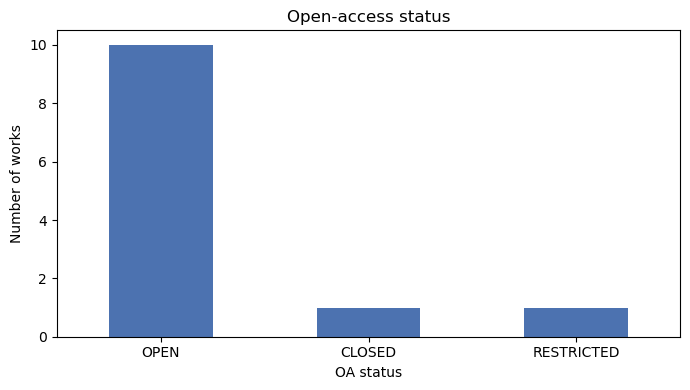

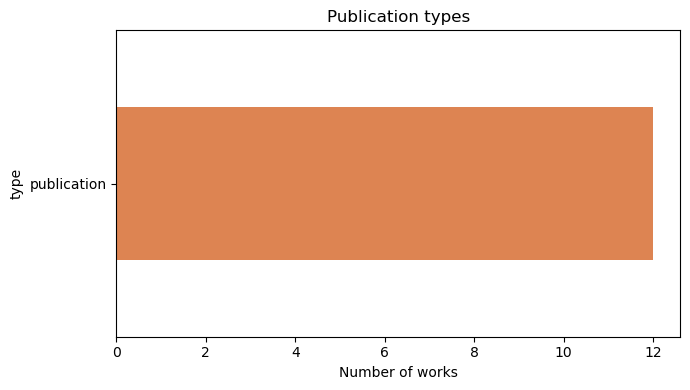

In [15]:
### Charts
# We can create simple charts to visualize the distribution of open-access status and publication types in our dataset using matplotlib

# 1. Open-access status distribution
oa_counts = df_pub["oa_status"].fillna("unknown").value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
oa_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Open-access status")
ax.set_xlabel("OA status")
ax.set_ylabel("Number of works")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("chart_oa_status.png", dpi=150)
plt.show()

# 2. Publication type distribution
type_counts = df_pub["type"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
type_counts.plot(kind="barh", ax=ax, color="#DD8452")
ax.set_title("Publication types")
ax.set_xlabel("Number of works")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart_work_types.png", dpi=150)
plt.show()


### 3) Explore relationships for a set of DOIs

This is a feature specific to the OpenAIRE Graph API: the **links endpoint** (`v1/researchProducts/links`) indexes relationships between research outputs, such as citations, dataset references, software links, and more.

Each DOI in the list is queried twice:
- as a **source** (`sourcePid`): links *originating* from this work (e.g. datasets it references)
- as a **target** (`targetPid`): links *pointing to* this work (e.g. papers that cite it)

Note: relationships are stored on the "active side" of the verb. "A cites B" is stored once, not also as "B isCitedBy A". Using `targetPid` is therefore the correct way to retrieve incoming citations.

API docs: https://graph.openaire.eu/docs/apis/scholexplorer/api


In [16]:
### Settings
# Reuses the DOIS list from section 2 -- or define a new one here
# DOIS = ["10.xxxx/...", ...]

In [17]:
### Fetch
all_rels = []

for doi in tqdm(DOIS, desc="Fetching relationships"):
    for direction in ("sourcePid", "targetPid"):
        resp = requests.get(
            f"{BASE_V1}/researchProducts/links",
            params={direction: doi, "page": 0},
        )
        resp.raise_for_status()
        data = resp.json()

        for rel in data.get("results") or []:
            source = rel.get("source") or {}
            target = rel.get("target") or {}
            all_rels.append({
                "query_doi":       doi,
                "query_direction": direction,
                "source_pid":      next((i.get("id") for i in source.get("identifiers") or [] if i.get("idScheme") == "doi"), None),
                "source_type":     source.get("type"),
                "source_title":    source.get("title"),
                "target_pid":      next((i.get("id") for i in target.get("identifiers") or [] if i.get("idScheme") == "doi"), None),
                "target_type":     target.get("type"),
                "target_title":    target.get("title"),
                "relationship":    (rel.get("relType") or {}).get("name"),
            })
        time.sleep(0.2)

print(f"Collected {len(all_rels)} relationships.")


Fetching relationships: 100%|██████████| 12/12 [00:11<00:00,  1.03it/s]

Collected 220 relationships.


In [18]:
### Build and save table
df_rels = pd.DataFrame(all_rels)
df_rels.to_csv("relationships.csv", index=False)
print(f"Saved {len(df_rels)} rows to relationships.csv")
df_rels.head(10)


Saved 220 rows to relationships.csv


,query_doi,query_direction,source_pid,source_type,source_title,target_pid,target_type,target_title,relationship
0,10.1186/s13045-024-01634-6,sourcePid,10.1186/s13045-024-01634-6,publication,Harnessing the tumor microenvironment: targete...,NaN,dataset,"A Phase 2, Two-arm, Double-blind, Multi-center...",cites
1,10.1186/s13045-024-01634-6,sourcePid,10.1186/s13045-024-01634-6,publication,Harnessing the tumor microenvironment: targete...,10.1186/s13045-022-01353-w,publication,BTK inhibitors in the treatment of hematologic...,cites
2,10.1186/s13045-024-01634-6,sourcePid,10.1186/s13045-024-01634-6,publication,Harnessing the tumor microenvironment: targete...,10.3390/cancers15041307,publication,Extracellular Vesicles in Liquid Biopsies as B...,cites
3,10.1186/s13045-024-01634-6,sourcePid,10.1186/s13045-024-01634-6,publication,Harnessing the tumor microenvironment: targete...,10.3389/fimmu.2012.00051,publication,Molecular Mechanisms of Treg-Mediated T Cell S...,cites
4,10.1186/s13045-024-01634-6,sourcePid,10.1186/s13045-024-01634-6,publication,Harnessing the tumor microenvironment: targete...,10.1158/1535-7163.mct-09-0150,publication,Inhibition of hypoxia-inducible factor-1 funct...,cites
5,10.1186/s13045-024-01634-6,sourcePid,10.1186/s13045-024-01634-6,publication,Harnessing the tumor microenvironment: targete...,10.3390/cancers15072156,publication,The Role of Exosomes in Epithelial–to-Mesenchy...,cites
6,10.1186/s13045-024-01634-6,sourcePid,10.1186/s13045-024-01634-6,publication,Harnessing the tumor microenvironment: targete...,10.1038/nm.3337,publication,CSF-1R inhibition alters macrophage polarizati...,cites
7,10.1186/s13045-024-01634-6,sourcePid,10.1186/s13045-024-01634-6,publication,Harnessing the tumor microenvironment: targete...,10.1158/2326-6066.cir-19-0507,publication,Cancer-Associated Fibroblasts Promote Immunosu...,cites
8,10.1186/s13045-024-01634-6,sourcePid,10.1186/s13045-024-01634-6,publication,Harnessing the tumor microenvironment: targete...,10.1038/s41598-020-74368-3,publication,The vitamin D analogue calcipotriol promotes a...,cites
9,10.1186/s13045-024-01634-6,sourcePid,10.1186/s13045-024-01634-6,publication,Harnessing the tumor microenvironment: targete...,10.1016/s1470-2045(22)00226-1,publication,Tiragolumab plus atezolizumab versus placebo p...,cites


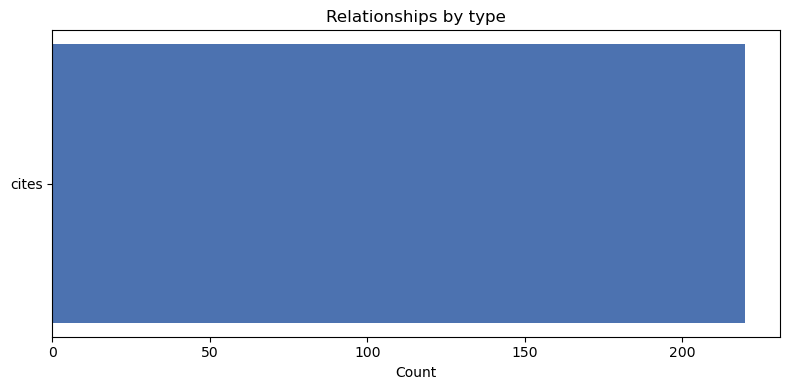

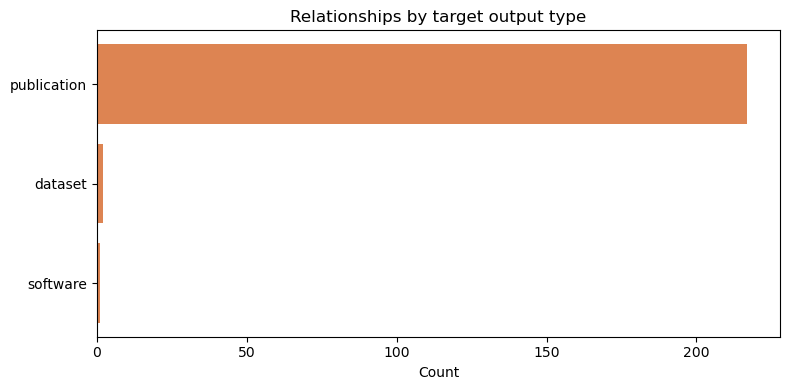

In [19]:
### Charts

# 1. Relationships by type (e.g. Cites, IsSupplementTo, IsRelatedTo)
by_rel = df_rels["relationship"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_rel.index, by_rel.values, color="#4C72B0")
ax.set_title("Relationships by type")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("chart_rels_by_type.png", dpi=150)
plt.show()

# 2. Relationships by target output type (publication / dataset / software / other)
by_target = df_rels["target_type"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_target.index, by_target.values, color="#DD8452")
ax.set_title("Relationships by target output type")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("chart_rels_by_target_type.png", dpi=150)
plt.show()


### 4) All works from an institution for a given year

This section demonstrates how to query works by an institution in a specific year, and then build tables of publications, authors, and subjects. We will use cursor-based pagination to retrieve all results if there are more than 100 (the default page size).

The institution is identified via its **ROR ID**. The research products endpoint filters on the internal OpenAIRE organisation ID, so we resolve ROR → OpenAIRE ID first. Look up ROR IDs at https://ror.org.

API docs: https://graph.openaire.eu/docs/apis/graph-api/searching-entities/filtering-search-results


In [20]:
### Settings
# Choose the institution
ROR_ID = "https://ror.org/008xxew50"
# Choose the year
YEAR = 2025
# Tune the number of results per page
PAGE_SIZE = 100


In [21]:
### Fetch -- resolve ROR to OpenAIRE organisation ID
# The research products endpoint uses the internal OpenAIRE org ID, not the ROR directly
resp = requests.get(
    f"{BASE_V1}/organizations",
    params={"pid": ROR_ID, "pageSize": 1},
)
resp.raise_for_status()
orgs = resp.json().get("results") or []

if not orgs:
    raise ValueError(f"No organisation found for ROR ID: {ROR_ID}")

ORG_ID = orgs[0]["id"]
print(f"Resolved: {orgs[0].get('legalName')} -> {ORG_ID}")


Resolved: Vrije Universiteit Amsterdam -> openorgs____::1624ff7c01bb641b91f4518539a0c28a


In [22]:
### Fetch
# Build the filter to query works affiliated with the resolved organisation in the chosen year
all_works = []
cursor = "*"

while cursor:
    resp = requests.get(
        f"{BASE_V2}/researchProducts",
        params={
            "relOrganizationId":   ORG_ID,
            "fromPublicationDate": f"{YEAR}-01-01",
            "toPublicationDate":   f"{YEAR}-12-31",
            "pageSize":            PAGE_SIZE,
            "cursor":              cursor,
        },
    )
    resp.raise_for_status()
    data = resp.json()

    all_works.extend(data.get("results") or [])

    total = (data.get("header") or {}).get("numFound", "?")
    print(f"Fetched {len(all_works)} / {total} works ...")

    cursor = (data.get("header") or {}).get("nextCursor")
    time.sleep(0.2)

print(f"Done. {len(all_works)} works retrieved.")


Fetched 100 / 11694 works ...
Fetched 200 / 11694 works ...
Fetched 300 / 11694 works ...
...Done. 11694 works retrieved.


In [23]:
### Build and save tables
# Initialize empty lists to store rows for each table
publications, authors, subjects = [], [], []

# For each work, we extract relevant metadata and append it to the publications list; we also extract author and subject information to build the authors and subjects tables
for w in all_works:
    wid = w.get("id")

    doi_val = next((p["value"] for p in w.get("pids") or [] if p.get("scheme") == "doi"), None)

    publications.append({
        "id":        wid,
        "title":     w.get("mainTitle"),
        "doi":       doi_val,
        "year":      (w.get("publicationDate") or "")[:4],
        "type":      w.get("type"),
        "oa_status": (w.get("bestAccessRight") or {}).get("label"),
        "publisher": w.get("publisher"),
        "journal":   (w.get("container") or {}).get("name"),
    })

    for auth in w.get("authors") or []:
        authors.append({
            "work_id":     wid,
            "author_name": auth.get("fullName"),
            "rank":        auth.get("rank"),
        })

    for subj in w.get("subjects") or []:
        subjects.append({
            "work_id": wid,
            "subject": subj.get("value"),
            "scheme":  subj.get("scheme"),
        })

# Convert lists of dictionaries to DataFrames
df_pub  = pd.DataFrame(publications)
df_auth = pd.DataFrame(authors)
df_subj = pd.DataFrame(subjects)

# Save to CSV files
df_pub.to_csv("publications.csv", index=False)
df_auth.to_csv("authors.csv", index=False)
df_subj.to_csv("subjects.csv", index=False)

# Print summary of results
print(f"Saved {len(df_pub)} publications, {len(df_auth)} authorships, {len(df_subj)} subjects.")


Saved 11694 publications, 107238 authorships, 102933 subjects.


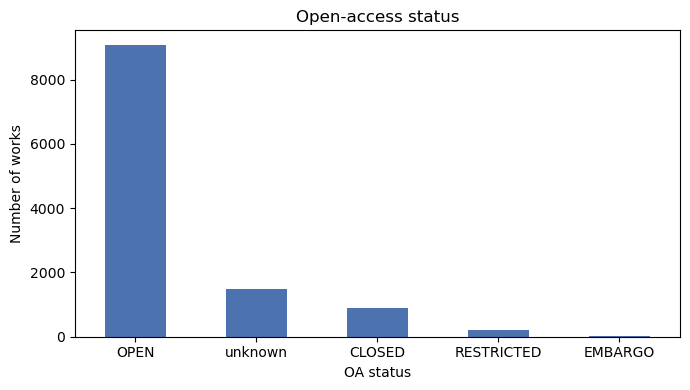

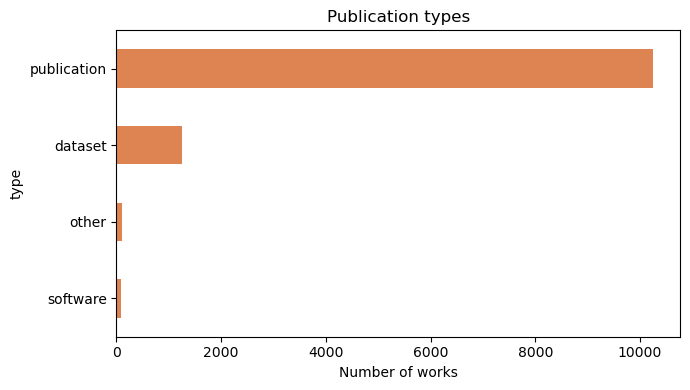

In [24]:
### Charts
# We can create simple charts to visualize the distribution of open-access status and publication types in our dataset using matplotlib

# 1. Open-access status distribution
oa_counts = df_pub["oa_status"].fillna("unknown").value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
oa_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Open-access status")
ax.set_xlabel("OA status")
ax.set_ylabel("Number of works")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("chart_oa_status.png", dpi=150)
plt.show()

# 2. Publication type distribution
type_counts = df_pub["type"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
type_counts.plot(kind="barh", ax=ax, color="#DD8452")
ax.set_title("Publication types")
ax.set_xlabel("Number of works")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart_work_types.png", dpi=150)
plt.show()


### 5) Data quality checks

Before analyzing a dataset from OpenAIRE, you may want to check a few things, for example:

- **Missing DOI** - many datasets, software, and reports are indexed under other identifier schemes (e.g. Handle, PMC), so a DOI-only join with another source will silently drop them.
- **Missing open-access status** - not every work has a `bestAccessRight` populated.


This section reuses the `all_works` list fetched in section 4 (all works from an institution in a given year) and produces a plain-language summary. If you haven't run section 3 yet, run it first.


In [ ]:
### Check data quality flags
# We go through every work in all_works (from section 4) and count how many fall into each quality-flag category.

total_works = len(all_works)

missing_doi_count = 0
missing_oa_status_count = 0

for work in all_works:

    # 1) Does this work have a DOI?
    has_doi = any(p.get("scheme") == "doi" for p in work.get("pids") or [])
    if not has_doi:
        missing_doi_count += 1

    # 2) Is the open-access status populated?
    if not work.get("bestAccessRight"):
        missing_oa_status_count += 1


### Report -- printed in plain language, no jargon
print(f"Total works checked: {total_works}")
print()

print(f"Missing open-access status : {missing_oa_status_count}  ({missing_oa_status_count/total_works:.1%} of the dataset)")


Total works checked: 11694

Missing open-access status : 1474  (12.6% of the dataset)


In [26]:
### Optional: keep only works that have a DOI
# This drops any work that has no DOI in its pids list.

works_with_doi = []

for work in all_works:
    has_doi = any(p.get("scheme") == "doi" for p in work.get("pids") or [])
    if has_doi:
        works_with_doi.append(work)

print(f"Kept {len(works_with_doi)} out of {len(all_works)} works that have a DOI.")

Kept 10111 out of 11694 works that have a DOI.


### 6) Boolean queries: AND / OR / NOT

This is another feature specific to the OpenAIRE Graph API: most filter parameters accept the logical operators `AND`, `OR`, and `NOT` directly inside the value, with parentheses for grouping.

A few rules to keep in mind:
- Wrap each value in double quotes if it contains spaces, e.g. `"open access"`.
- `OR` is also what you get for free by repeating a parameter or separating values with a comma. Writing `OR` explicitly just makes the query easier to read.
- Parentheses let you combine `AND`/`OR`/`NOT` in the same query, the same way you would in a spreadsheet formula.

API docs: https://graph.openaire.eu/docs/apis/graph-api/searching-entities/filtering-search-results


In [27]:
### Settings
# Two keywords we want BOTH to be present in the subjects of a work
KEYWORD_1 = "bibliometrics"
KEYWORD_2 = "open access"


In [28]:
### Fetch -- AND: works whose subjects mention BOTH keywords
and_filter = f'"{KEYWORD_1}" AND "{KEYWORD_2}"'

resp = requests.get(
    f"{BASE_V2}/researchProducts",
    params={"subjects": and_filter, "pageSize": 10},
)
resp.raise_for_status()
data = resp.json()

print(f"Query: subjects = {and_filter}")
print(f"Total matching works: {(data.get('header') or {}).get('numFound', '?')}")


Query: subjects = "bibliometrics" AND "open access"
Total matching works: 514


In [29]:
### Fetch -- OR / NOT combined with parentheses
# Works whose subjects mention EITHER keyword, but exclude anything also tagged "preprint"
combined_filter = f'("{KEYWORD_1}" OR "{KEYWORD_2}") AND NOT "preprint"'

resp = requests.get(
    f"{BASE_V2}/researchProducts",
    params={"subjects": combined_filter, "pageSize": 10},
)
resp.raise_for_status()
data = resp.json()

print(f"Query: subjects = {combined_filter}")
print(f"Total matching works: {(data.get('header') or {}).get('numFound', '?')}")


Query: subjects = ("bibliometrics" OR "open access") AND NOT "preprint"
Total matching works: 82128
